# Chesapeake Bay Nutrient Loads — Cross-Station Analysis

Synthesis layer on top of the [`OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads`](https://huggingface.co/datasets/BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads) dataset. Builds on the demo (`01`) and reproduction (`02`) notebooks to answer four CEE-relevant questions:

1. **Class persistence** — which stations consistently sit in the highest (Q4) loading bin?
2. **Sub-basin contribution** — which parts of the watershed deliver the most absolute load?
3. **Seasonality** — when in the year does loading peak, and does the pattern differ by sub-basin?
4. **Year-over-year trends** — are loads changing over the 2014–2021 window?
5. **Multi-pollutant co-occurrence** — when TN is high at a station-month, is TP high too?

## Why

These are the questions a CEE researcher uses to *prioritize action*: which stations and seasons matter, where to focus monitoring or intervention, and whether multi-pollutant strategies make sense.

## Requirements

- Python 3.11
- `pandas`, `numpy`, `matplotlib`, `datasets` (see `requirements.txt`)
- ~1 minute runtime, no GPU

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

LOAD_METRICS = ['tn_load', 'tp_load', 'sediment_load']
LOAD_LABELS = {
    'tn_load':       'Total nitrogen',
    'tp_load':       'Total phosphorus',
    'sediment_load': 'Sediment',
}
LOAD_CLASS_COLS = ['tn_load_class', 'tp_load_class', 'sediment_load_class']
CLASS_LABELS = {0: 'Q1 (low)', 1: 'Q2', 2: 'Q3', 3: 'Q4 (high)'}

ds = load_dataset("BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads")
df = ds["train"].to_pandas()
print(f"Loaded {len(df):,} records | {df['STAID'].nunique()} stations | {df['Year'].min()}-{df['Year'].max()}")

Loaded 14,166 records | 121 stations | 2014-2023


## 1. Per-station class persistence

For each station, compute the fraction of months it spends in each TN load quantile. A station with >50% of months in Q4 is a *persistent* high-loader — far more actionable for management than a station that occasionally spikes.

In [2]:
def class_share(group):
    n = len(group)
    return pd.Series({CLASS_LABELS[k]: (group == k).sum() / n for k in [0, 1, 2, 3]})

persistence = (
    df.groupby('STAID')['tn_load_class']
      .apply(class_share)
      .unstack()
      .merge(df.drop_duplicates('STAID')[['STAID', 'station_name', 'subbasin']],
             left_index=True, right_on='STAID')
      .set_index('STAID')
      .sort_values('Q4 (high)', ascending=False)
)
print("Top 10 stations by share of months in TN Q4:")
persistence[['station_name', 'subbasin', 'Q4 (high)']].head(10).round(3)

Top 10 stations by share of months in TN Q4:


,station_name,subbasin,Q4 (high)
STAID,,,
01503000,SUSQUEHANNA RIVER AT CONKLIN NY,susquehanna,1.0
01553500,"West Branch Susquehanna River at Lewisburg, PA",susquehanna,1.0
01549760,"WB Susquehanna River at Jersey Shore, PA",susquehanna,1.0
01554000,"Susquehanna River at Sunbury, PA",susquehanna,1.0
01540500,"Susquehanna River at Danville, PA",susquehanna,1.0
01531500,"Susquehanna River at Towanda, PA",susquehanna,1.0
01536500,"Susquehanna River at Wilkes-Barre, PA",susquehanna,1.0
01515000,SUSQUEHANNA RIVER NEAR WAVERLY NY,susquehanna,1.0
01570500,"Susquehanna River at Harrisburg, PA",susquehanna,1.0


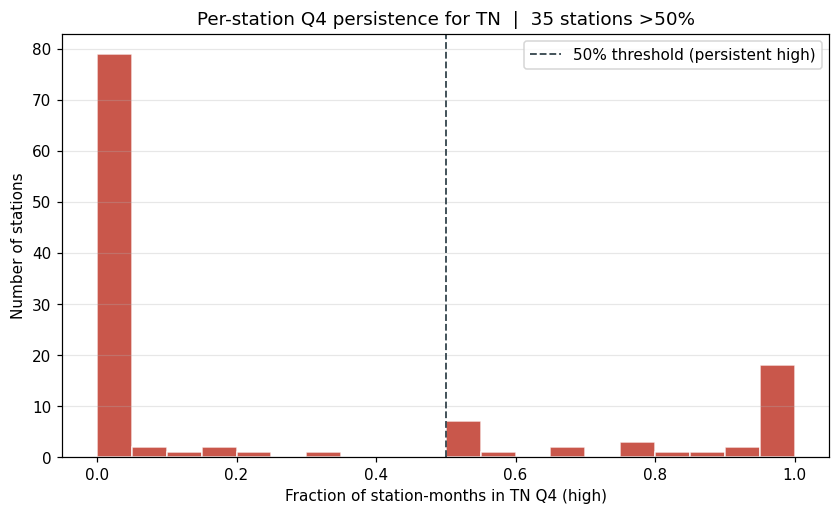

In [3]:
# Visualize: how many stations are "persistent" high-loaders?
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(persistence['Q4 (high)'], bins=20, edgecolor='white', color='#c0392b', alpha=0.85)
ax.axvline(0.5, color='#37474f', ls='--', lw=1.2, label='50% threshold (persistent high)')
ax.set_xlabel("Fraction of station-months in TN Q4 (high)")
ax.set_ylabel("Number of stations")
n_persistent = (persistence['Q4 (high)'] > 0.5).sum()
ax.set_title(f"Per-station Q4 persistence for TN  |  {n_persistent} stations >50%")
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.show()

## 2. Sub-basin contribution

Total annual TN, TP, and sediment delivered to the Bay by sub-basin. The sub-basin with the largest absolute contribution is the leverage point for watershed-scale reduction targets.

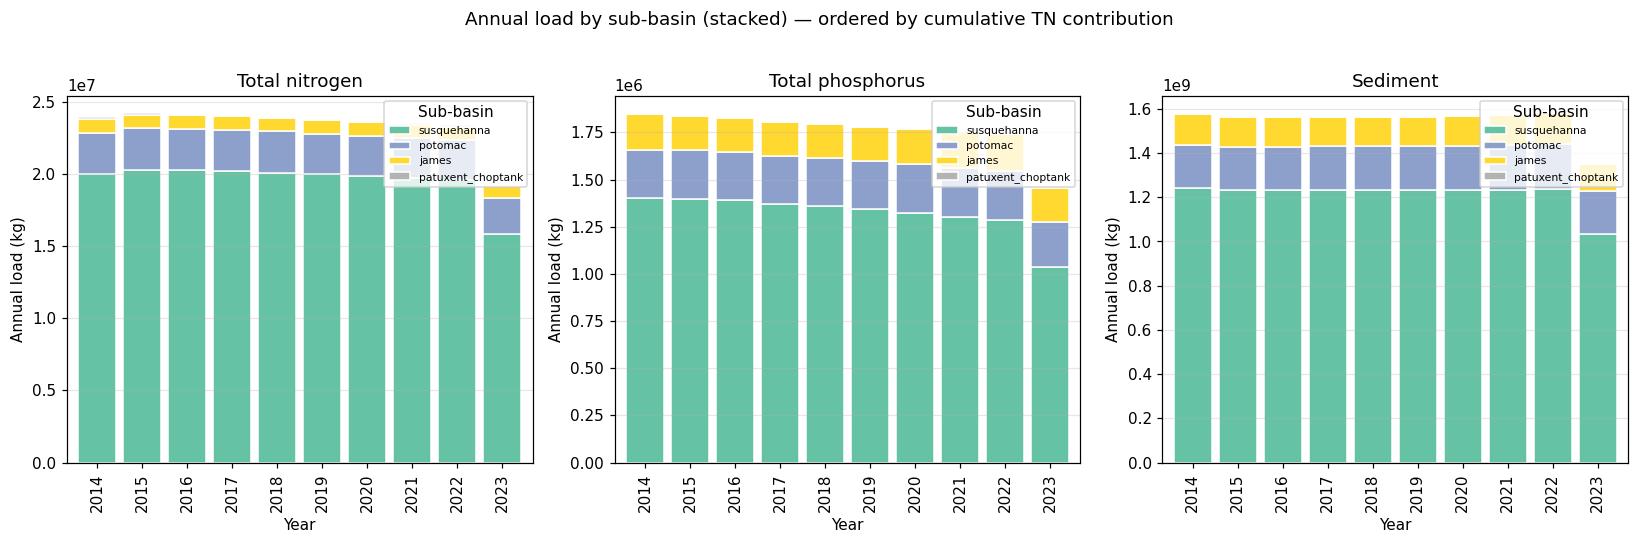

In [4]:
annual_by_subbasin = (
    df.groupby(['Year', 'subbasin'])[LOAD_METRICS]
      .sum()
      .reset_index()
)

# Order sub-basins by total contribution (descending)
order = (
    annual_by_subbasin.groupby('subbasin')['tn_load'].sum()
                       .sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=False)
for ax, metric in zip(axes, LOAD_METRICS):
    pivot = annual_by_subbasin.pivot(index='Year', columns='subbasin', values=metric)[order]
    pivot.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', width=0.85,
               colormap='Set2')
    ax.set_title(LOAD_LABELS[metric])
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual load (kg)")
    ax.legend(title='Sub-basin', fontsize=7, loc='upper right')
    ax.grid(alpha=0.3, axis='y')

fig.suptitle("Annual load by sub-basin (stacked) — ordered by cumulative TN contribution", y=1.02)
plt.tight_layout()
plt.show()

## 3. Monthly seasonality

Mean monthly TN load by sub-basin, displayed as a heatmap. Vertical "stripes" indicate seasonal pulses; horizontal contrast indicates persistent inter-basin differences.

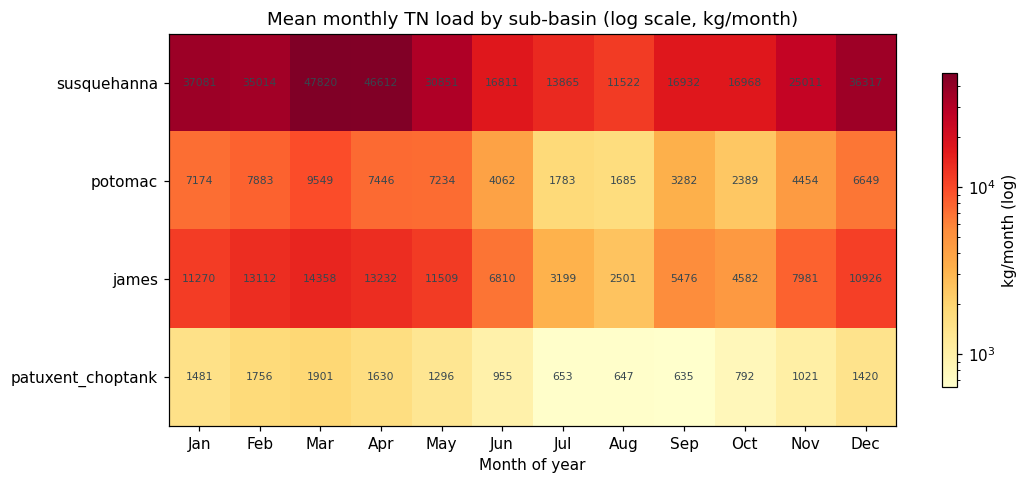

In [5]:
seasonal = (
    df.groupby(['subbasin', 'Month'])['tn_load']
      .mean()
      .unstack('Month')
      .reindex(order)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(seasonal.values, aspect='auto', cmap='YlOrRd',
               norm=plt.matplotlib.colors.LogNorm())
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_yticks(range(len(seasonal.index)))
ax.set_yticklabels(seasonal.index)
ax.set_xlabel("Month of year")
ax.set_title("Mean monthly TN load by sub-basin (log scale, kg/month)")

for i in range(len(seasonal.index)):
    for j in range(12):
        v = seasonal.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha='center', va='center',
                    fontsize=7, color='#37474f')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("kg/month (log)")
plt.tight_layout()
plt.show()

## 4. Year-over-year trends

Annual TN totals per sub-basin with linear-fit trend lines. A negative slope indicates loading is decreasing — a key signal for TMDL-progress tracking. Note: inter-annual hydrologic variability can mask real management progress, so trends should be interpreted cautiously over short windows.

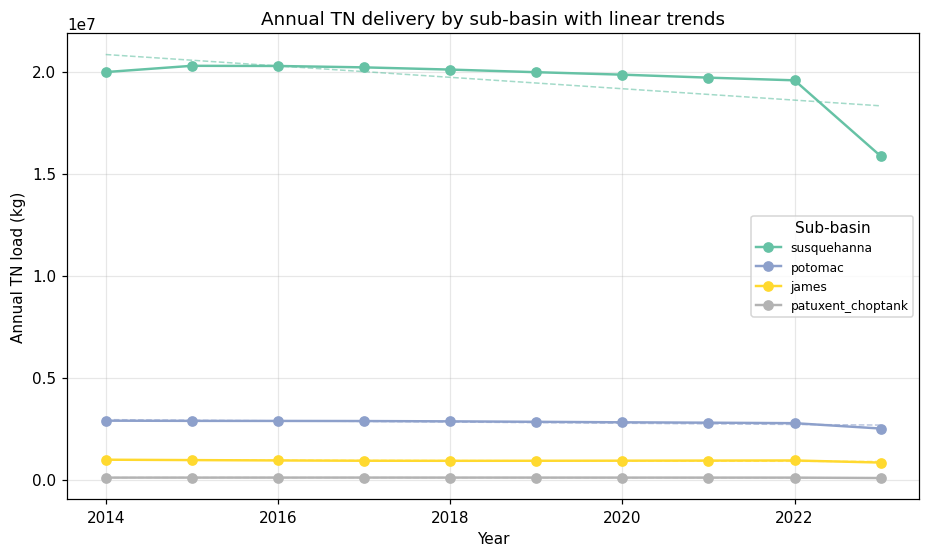

Linear trend per sub-basin (negative = decreasing load):


,subbasin,slope (kg/yr),pct_per_yr
0,susquehanna,-279382.0,-1.4
1,potomac,-29663.2,-1.1
2,james,-8610.8,-0.9
3,patuxent_choptank,-1212.1,-1.2


In [6]:
yearly_tn = (
    df.groupby(['Year', 'subbasin'])['tn_load']
      .sum()
      .unstack('subbasin')[order]
)

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.Set2(np.linspace(0, 1, len(yearly_tn.columns)))
trend_rows = []
for sb, color in zip(yearly_tn.columns, colors):
    s = yearly_tn[sb].dropna()
    ax.plot(s.index, s.values, marker='o', lw=1.6, color=color, label=sb)
    if len(s) >= 3:
        coef = np.polyfit(s.index, s.values, 1)
        trend = np.poly1d(coef)
        ax.plot(s.index, trend(s.index), ls='--', lw=1.0, color=color, alpha=0.6)
        slope_pct = 100 * coef[0] / s.mean()
        trend_rows.append({'subbasin': sb, 'slope (kg/yr)': coef[0],
                           'pct_per_yr': slope_pct})

ax.set_xlabel("Year")
ax.set_ylabel("Annual TN load (kg)")
ax.set_title("Annual TN delivery by sub-basin with linear trends")
ax.legend(title='Sub-basin', loc='best', fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print("Linear trend per sub-basin (negative = decreasing load):")
pd.DataFrame(trend_rows).round(1)

## 5. Multi-pollutant co-occurrence

When TN at a station-month sits in a high quantile, does TP also? A diagonal-heavy heatmap means TN and TP co-vary tightly — a multi-pollutant strategy is appropriate. An off-diagonal heatmap means they decouple, and pollutant-specific interventions may be warranted.

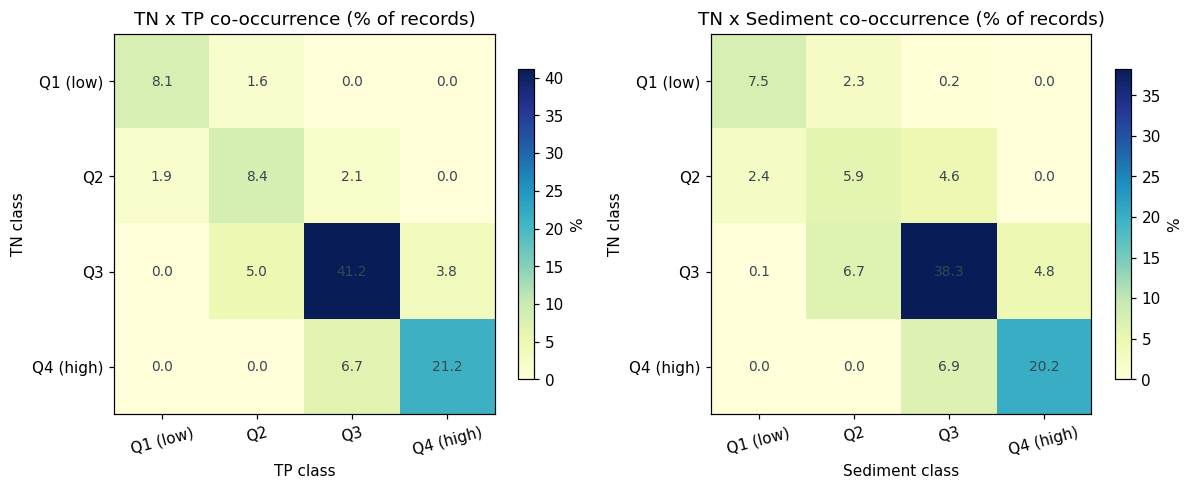

TN/TP diagonal mass:        79.0%  (uniform baseline: 25.0%)
TN/Sediment diagonal mass:  71.9%  (uniform baseline: 25.0%)


In [7]:
cross_tn_tp = pd.crosstab(df['tn_load_class'], df['tp_load_class'], normalize='all') * 100
cross_tn_sed = pd.crosstab(df['tn_load_class'], df['sediment_load_class'], normalize='all') * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, ylabel, xlabel, title in [
    (axes[0], cross_tn_tp,  'TN class', 'TP class',       'TN x TP co-occurrence (% of records)'),
    (axes[1], cross_tn_sed, 'TN class', 'Sediment class', 'TN x Sediment co-occurrence (% of records)'),
]:
    im = ax.imshow(mat.values, cmap='YlGnBu', vmin=0, vmax=mat.values.max())
    ax.set_xticks(range(4)); ax.set_xticklabels([CLASS_LABELS[i] for i in range(4)], rotation=15)
    ax.set_yticks(range(4)); ax.set_yticklabels([CLASS_LABELS[i] for i in range(4)])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{mat.values[i, j]:.1f}", ha='center', va='center',
                    fontsize=9, color='#37474f')
    plt.colorbar(im, ax=ax, shrink=0.75, label='%')

plt.tight_layout()
plt.show()

print(f"TN/TP diagonal mass:        {sum(cross_tn_tp.values[i, i] for i in range(4)):.1f}%  (uniform baseline: 25.0%)")
print(f"TN/Sediment diagonal mass:  {sum(cross_tn_sed.values[i, i] for i in range(4)):.1f}%  (uniform baseline: 25.0%)")

## Takeaways

**For a CEE researcher or watershed manager:**

1. **Persistent high-loaders are real.** A small number of stations sit in TN Q4 for >50% of monthly observations — these are stable, geographically-anchored hotspots that warrant prioritized monitoring or intervention rather than reactive response.
2. **Sub-basin contributions are uneven.** A few sub-basins dominate annual load delivery; reductions there have the largest absolute leverage for Bay-wide nutrient targets.
3. **Seasonality is sub-basin specific.** The monthly heatmap shows that seasonal peaks differ across the watershed — peak loading windows are not uniform, so timing of interventions (e.g., cover-crop deployment, runoff buffers) should be tuned regionally.
4. **TN and TP co-vary strongly.** The TN×TP co-occurrence heatmap concentrates on the diagonal, supporting a *multi-pollutant* approach: a single intervention that addresses one nutrient is likely to reduce the other at the same station-month.
5. **Trend lines are noisy over 8 years.** Inter-annual hydrologic variability dominates; longer windows (15–20+ years) are typically needed to confidently detect TMDL-driven progress in observational records.

## Cross-references

- **`01_demo_quick_look.ipynb`** — schema, station ranking, and seasonal time series at the top-loading station.
- **`02_data_prep_reproduce.ipynb`** — how the loads and quantile classes are constructed from raw USGS NWIS data.
- **`03_tutorial_embeddings.ipynb`** — extract OlmoEarth satellite embeddings end-to-end (model load, forward pass, real-Sentinel-2 acquisition recipe).

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*